# Bitcoin forecast and visualization in dashboard - tf_bitcoin.example.ipynb
An interactive notebook demonstrating how to interact with the deployed real-time Bitcoin forecasting API and visualize the predictions.

## How to Use `tf_bitcoin.example.ipynb`

This notebook demonstrates how to interact with the deployed Bitcoin forecasting API and visualize predictions.

Before running this notebook, you **must first start the API and dashboard** using Docker.

### Step-by-Step Instructions

1. **Build the Docker image** (from your project root directory):
   ```bash
   docker build -t bitcoin-dashboard .
2. **Run the Docker container:
    ```bash
    docker run -p 5000:5000 -p 5001:5001 bitcoin-dashboard
3. Start running the following commands or go to
    - The Flask dashboard on http://localhost:5000
    - The prediction API on http://localhost:5001


In [ ]:
# Step 1: Import necessary libraries
import requests
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

In [ ]:
response = requests.get("http://localhost:5001/forecast")
data = response.json()

In [ ]:
forecast_data = data['forecast']

In [ ]:
df_plot = pd.DataFrame(forecast_data)

In [ ]:
df_plot['timestamp'] = pd.to_datetime(df_plot['timestamp'])
df_plot.set_index('timestamp', inplace=True)

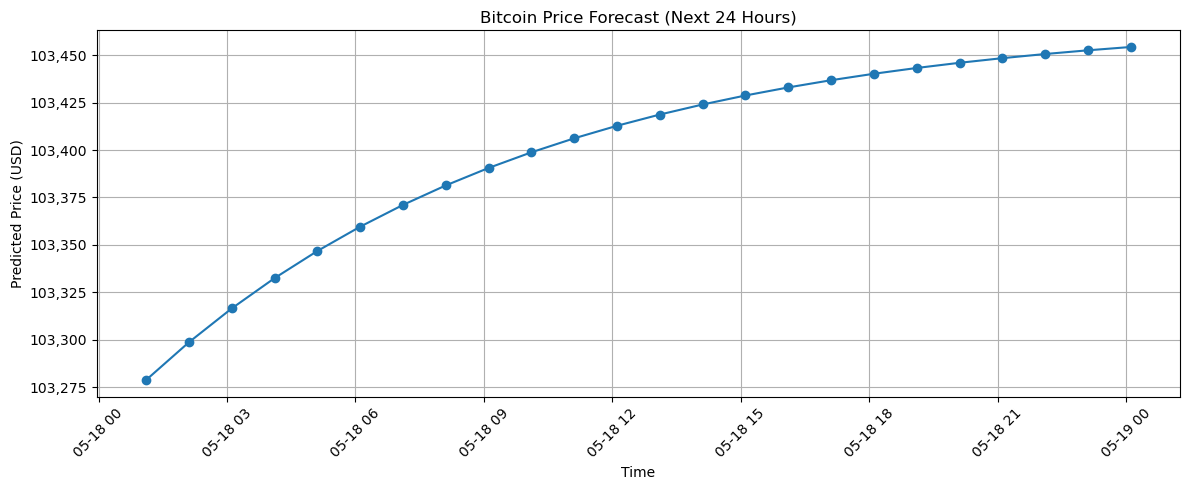

In [8]:
formatter = FuncFormatter(lambda y, _: f'{y:,.0f}') 

plt.figure(figsize=(12, 5))
plt.plot(df_plot.index, df_plot['price'], marker='o', label='Forecasted Price')
plt.title("Bitcoin Price Forecast (Next 24 Hours)")
plt.xlabel("Time")
plt.ylabel("Predicted Price (USD)")
plt.grid(True)
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(formatter)

try:
    current_price = data[0]['current_price']
    plt.axhline(y=current_price, color='red', linestyle='--', label='Current Price')
    plt.legend()
except Exception:
    pass

plt.tight_layout()
plt.show()

In [9]:
df_plot.to_csv("bitcoin_forecast_output.csv")
print("Forecast saved to bitcoin_forecast_output.csv")

Forecast saved to bitcoin_forecast_output.csv
